# Lab 20: Reinforcement learning with Q-learning

Authored deterministic 4x4 grid environment and exported state-action transition dataset. Q-learning with fixed seed. RL has no label accuracy, so the reported metric is greedy-policy goal success over all 15 non-terminal start states, with path lengths. Toy task, not a general RL benchmark.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


Evaluation success rate (not supervised accuracy): 1.0
Successful starts: 15 /15
Mean successful path length: 3.2
Greedy path from start: [0, 4, 5, 9, 10, 14, 15]


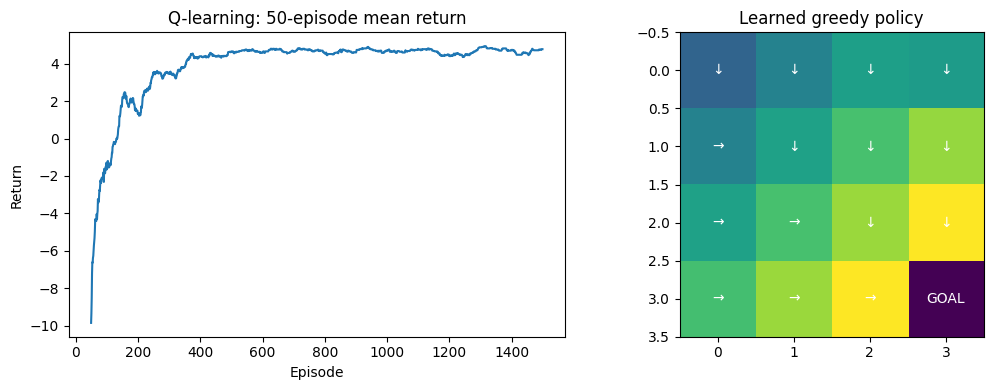

In [2]:
import pandas as pd

size=4;goal=15;actions=[(-1,0),(0,1),(1,0),(0,-1)]
def transition(state,action):
 r,c=divmod(state,size);dr,dc=actions[action];nr,nc=np.clip(r+dr,0,size-1),np.clip(c+dc,0,size-1);next_state=int(nr*size+nc);done=next_state==goal
 return next_state,(10.0 if done else -1.0),done
rows=[]
for state in range(16):
 for action in range(4):
  next_state,reward,done=transition(state,action);rows.append([state,action,next_state,reward,done])
pd.DataFrame(rows,columns=['State','Action','NextState','Reward','Terminal']).to_csv('grid_transitions.csv',index=False)
rng=np.random.default_rng(42);Q=np.zeros((16,4));alpha=.2;gamma=.95;returns=[]
for episode in range(1500):
 state=0;total=0;epsilon=max(.05,.8*(.995**episode))
 for step in range(100):
  action=int(rng.integers(4)) if rng.random()<epsilon else int(np.argmax(Q[state]));next_state,reward,done=transition(state,action);target=reward if done else reward+gamma*np.max(Q[next_state]);Q[state,action]+=alpha*(target-Q[state,action]);state=next_state;total+=reward
  if done:break
 returns.append(total)

successes=0;lengths=[]
for start in range(15):
 state=start
 for step in range(100):
  state,reward,done=transition(state,int(np.argmax(Q[state])))
  if done:successes+=1;lengths.append(step+1);break
print('Evaluation success rate (not supervised accuracy):',successes/15);print('Successful starts:',successes,'/15');print('Mean successful path length:',np.mean(lengths))
state=0;path=[state]
for step in range(100):
 state,_,done=transition(state,int(np.argmax(Q[state])));path.append(state)
 if done:break
print('Greedy path from start:',path);np.savetxt('q_table.csv',Q,delimiter=',',header='up,right,down,left',comments='')
fig,axs=plt.subplots(1,2,figsize=(11,4));axs[0].plot(pd.Series(returns).rolling(50).mean());axs[0].set(title='Q-learning: 50-episode mean return',xlabel='Episode',ylabel='Return');axs[1].imshow(np.max(Q,axis=1).reshape(4,4),cmap='viridis');arrows=['↑','→','↓','←']
for s in range(16):
 r,c=divmod(s,4);axs[1].text(c,r,'GOAL' if s==goal else arrows[np.argmax(Q[s])],ha='center',va='center',color='white')
axs[1].set_title('Learned greedy policy');plt.tight_layout();plt.show()
